<a href="https://colab.research.google.com/github/TranMinhHuy15/CPV301/blob/main/3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_iris

# Tải tập dữ liệu Iris
iris = load_iris()

# Tạo DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

In [ ]:
# Hiển thị 5 dòng đầu tiên
print("--- 5 dòng đầu tiên của dữ liệu ---")
display(df.head())

--- 5 dòng đầu tiên của dữ liệu ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


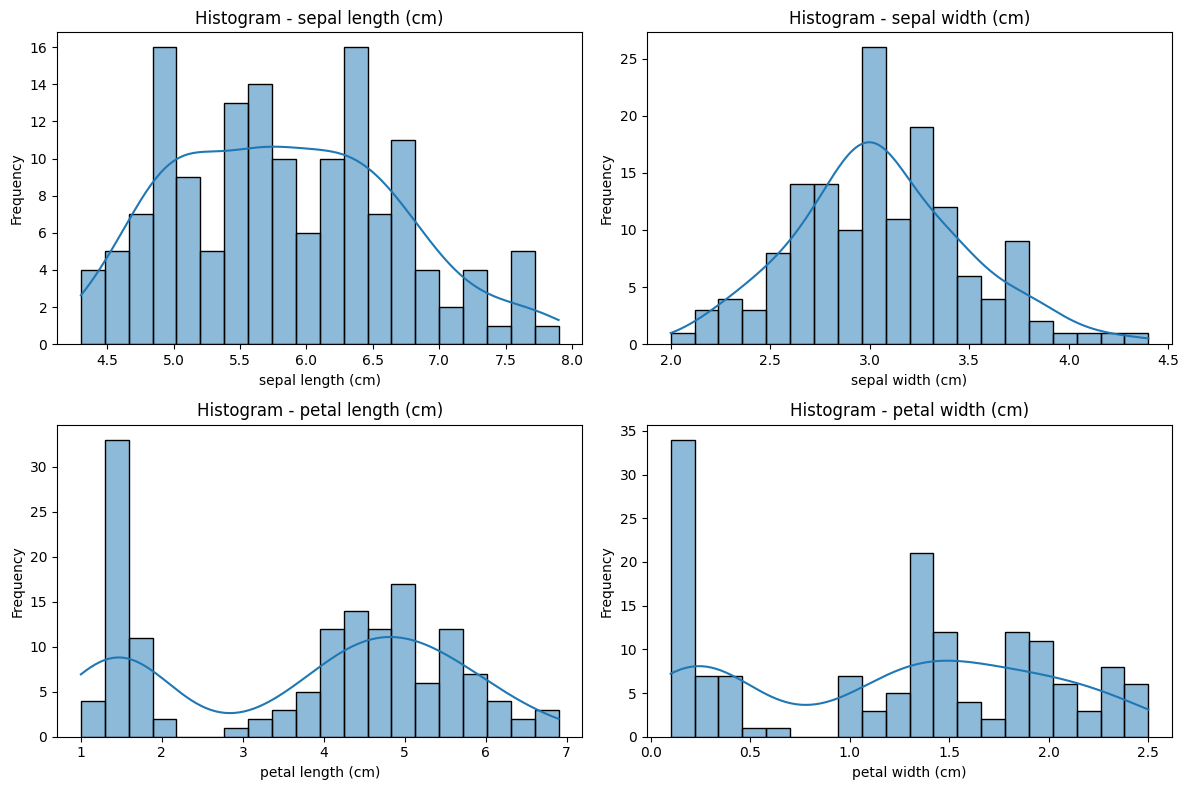

In [ ]:
# Histogram bằng Seaborn

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = iris.feature_names

for ax, feature in zip(axes.flat, features):
    sns.histplot(df[feature], bins=20, kde=True, ax=ax)
    ax.set_title(f"Histogram - {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

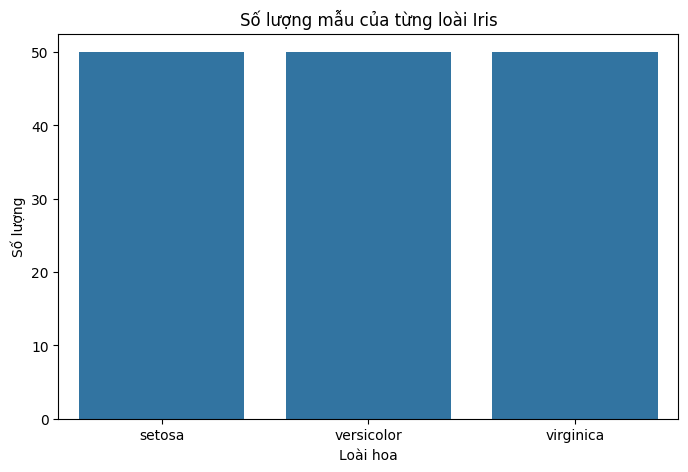

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Biểu đồ số lượng từng loài Iris
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='species')

plt.title("Số lượng mẫu của từng loài Iris")
plt.xlabel("Loài hoa")
plt.ylabel("Số lượng")

plt.show()

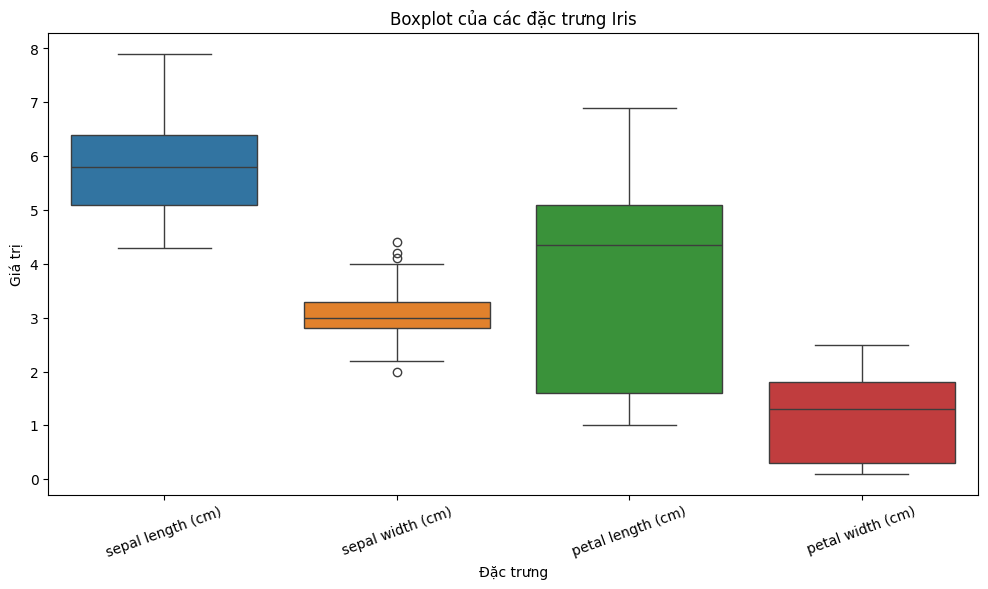

In [ ]:
# Boxplot của các đặc trưng Iris

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[iris.feature_names])

plt.title("Boxplot của các đặc trưng Iris")
plt.xlabel("Đặc trưng")
plt.ylabel("Giá trị")

plt.xticks(rotation=20)

plt.show()

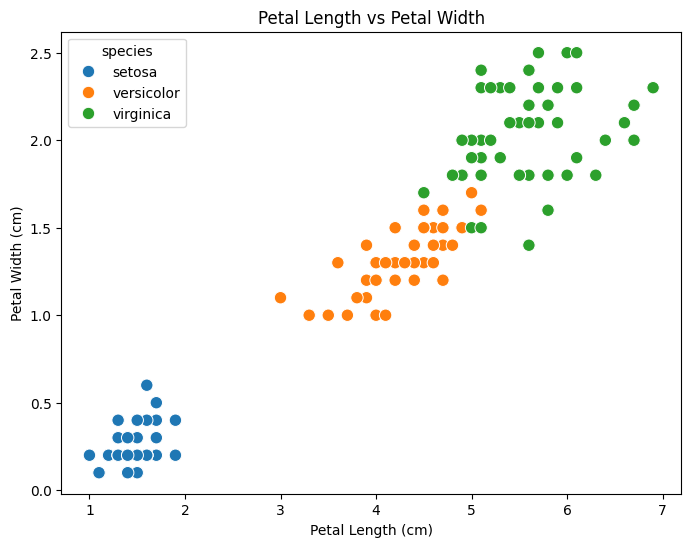

In [ ]:
# Scatter plot: Petal Length vs Petal Width

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

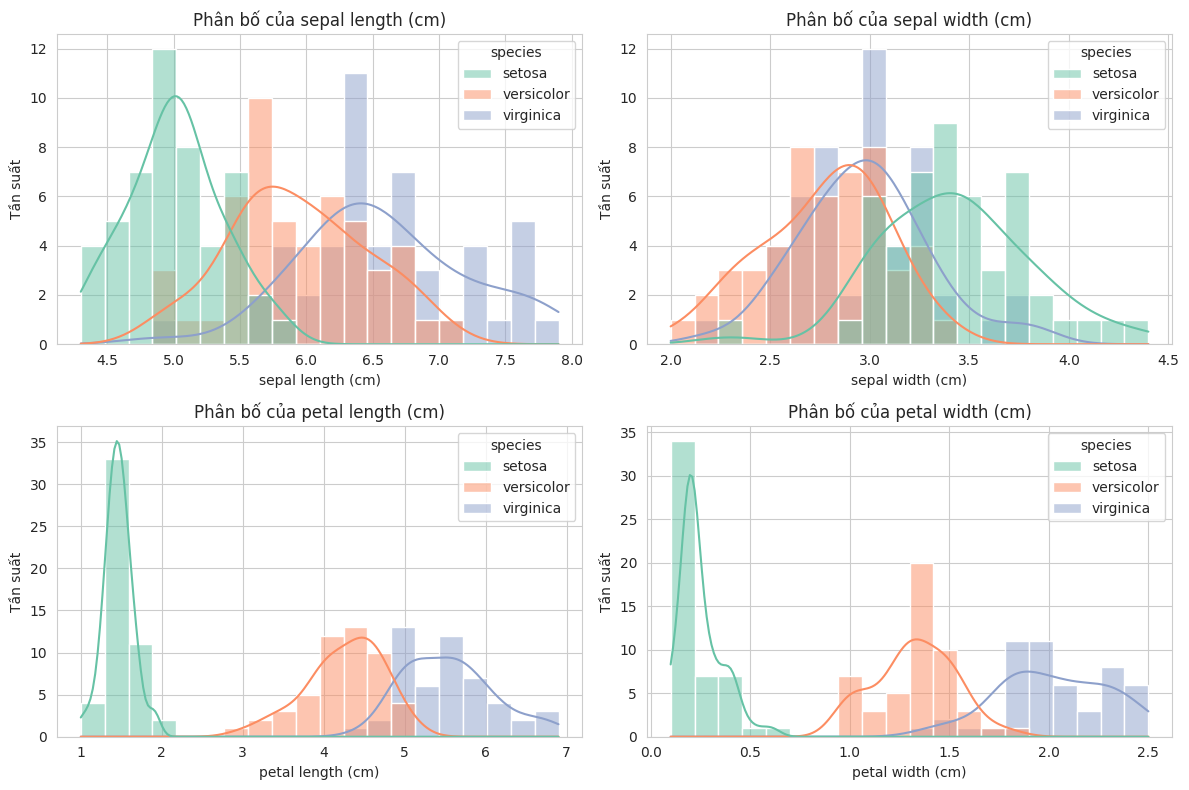

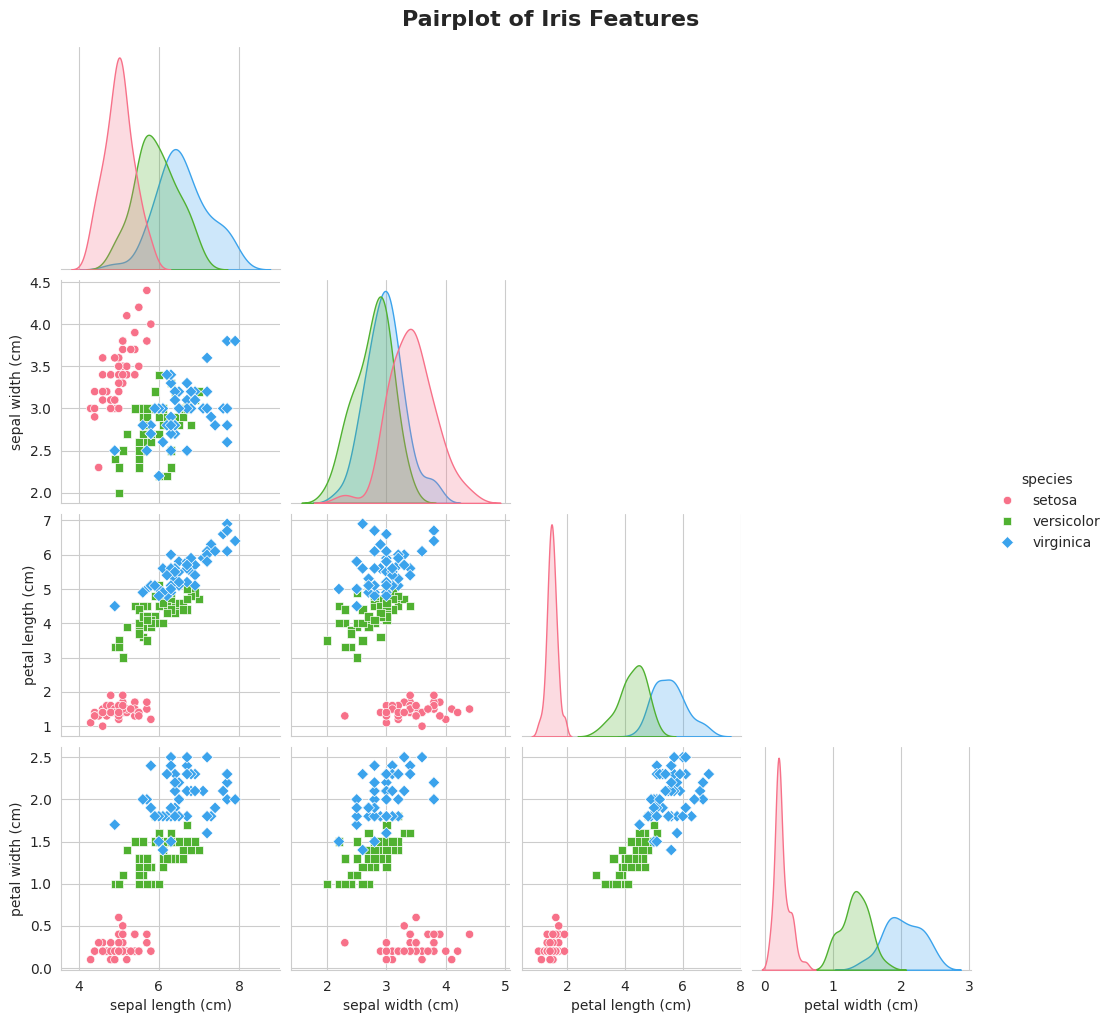

In [ ]:
# Thiết lập giao diện biểu đồ
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Vẽ histogram cho từng đặc trưng (feature) trong tập dữ liệu Iris
for i, col in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, hue='species', kde=True, bins=20, palette='Set2')
    plt.title(f'Phân bố của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

# Bỏ cột 'target' (số 0, 1, 2) để không vẽ vào biểu đồ, chỉ giữ lại 'species' (chữ)
df_plot = df.drop(columns=['target'])

# Vẽ Pairplot
sns.pairplot(df_plot, hue='species', palette='husl', markers=["o", "s", "D"], corner=True)

plt.suptitle('Pairplot of Iris Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()


In [ ]:
print("\n-----------Thông tin dữ liệu")
df.info()


-----------Thông tin dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


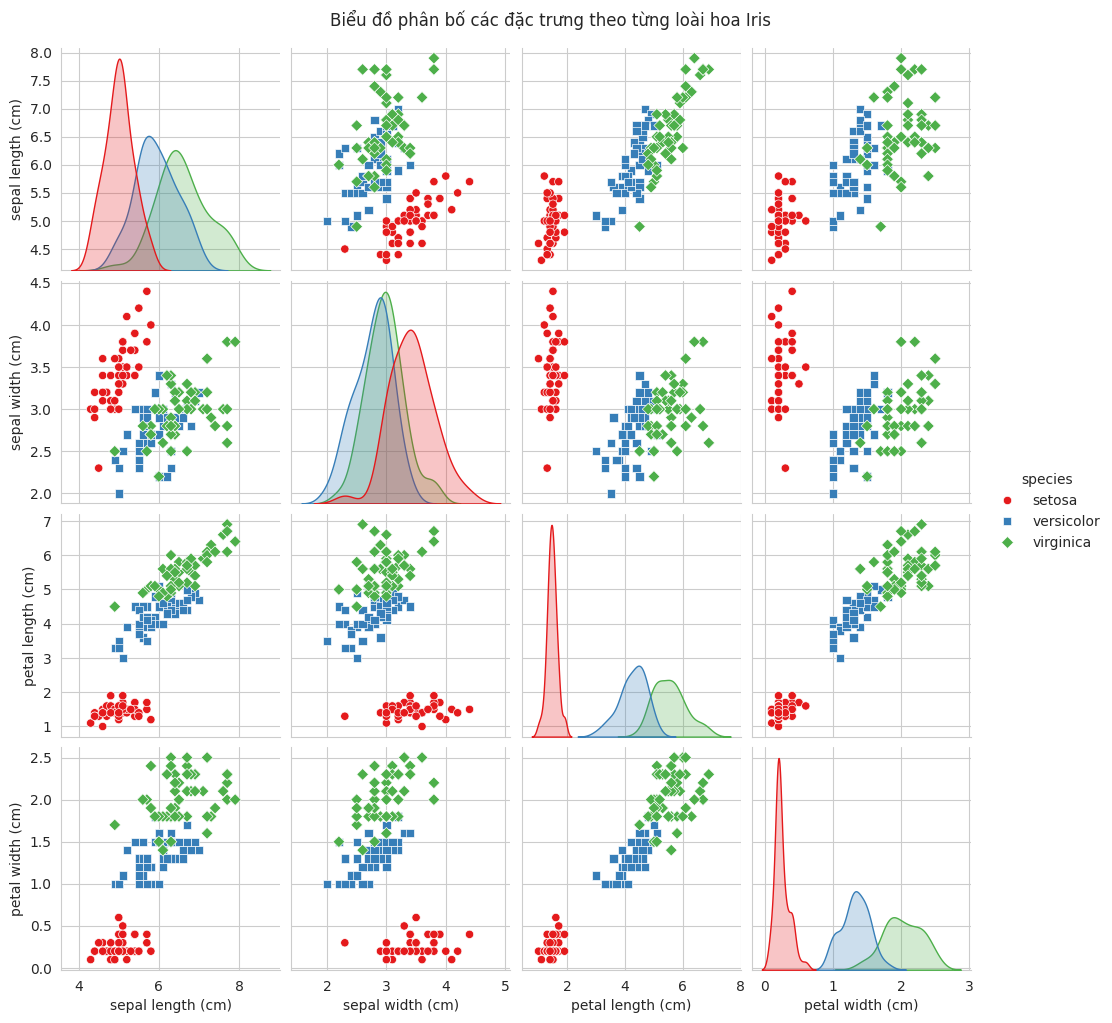

In [ ]:
# Trực quan hóa phân bố các loài hoa bằng Pairplot
sns.pairplot(
    df.drop('target', axis=1),
    hue='species',
    palette='Set1',
    markers=["o", "s", "D"]
)

plt.suptitle(
    "Biểu đồ phân bố các đặc trưng theo từng loài hoa Iris",
    y=1.02
)

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Khai báo X (đặc trưng) và y (nhãn)
X = iris.data
y = iris.target

# Chia dữ liệu theo tỉ lệ 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập Train (X_train): {X_train.shape}")
print(f"Kích thước tập Test (X_test): {X_test.shape}")

Kích thước tập Train (X_train): (120, 4)
Kích thước tập Test (X_test): (30, 4)


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Khởi tạo mô hình Gaussian Naive Bayes
model = GaussianNB()

# Huấn luyện mô hình
model.fit(X_train, y_train)

print("Đã huấn luyện xong mô hình Gaussian Naive Bayes")

Đã huấn luyện xong mô hình Gaussian Naive Bayes


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dự đoán nhãn trên tập Test
y_pred = model.predict(X_test)

# Tính độ chính xác (Accuracy)
acc = accuracy_score(y_test, y_pred)

print(f"Độ chính xác (Accuracy) trên tập Test: {acc * 100:.2f}%\n")

Độ chính xác (Accuracy) trên tập Test: 96.67%



In [ ]:
# In report (Precision, Recall, F1-Score)
print("--- Báo cáo chi tiết (Classification Report) ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

--- Báo cáo chi tiết (Classification Report) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



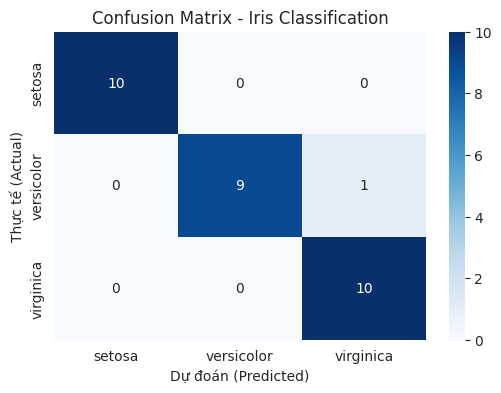

In [ ]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - Iris Classification')

plt.show()

In [ ]:
# Mẫu hoa mới: [sepal length, sepal width, petal length, petal width]
# Ví dụ: 5.1 cm, 3.5 cm, 1.4 cm, 0.2 cm
sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# Dự đoán lớp
pred_class = model.predict(sample)[0]
pred_species = iris.target_names[pred_class]

# Tính xác suất cụ thể cho từng lớp
probabilities = model.predict_proba(sample)[0]

print(f"Mẫu hoa nhập vào thuộc loài: >>> {pred_species.upper()} <<<")
print("\nXác suất tương ứng với từng loài:")

for i, species_name in enumerate(iris.target_names):
    print(f" - {species_name}: {probabilities[i] * 100:.2f}%")

Mẫu hoa nhập vào thuộc loài: >>> SETOSA <<<

Xác suất tương ứng với từng loài:
 - setosa: 100.00%
 - versicolor: 0.00%
 - virginica: 0.00%


In [ ]:
!pip install gradio

In [ ]:
from google.colab import drive
import os

# Kết nối Google Drive
drive.mount('/content/drive')

# Folder đúng của bạn
image_folder = "/content/drive/MyDrive/AIL"

# Tìm tất cả ảnh
image_files = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Số ảnh tìm được:", len(image_files))

for img in image_files:
    print(img)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Số ảnh tìm được: 3
/content/drive/MyDrive/AIL/1790997729001_7354821207393046161_g4143574980947886080_e3084215504a0fedd6d558ea6c050578.jpg
/content/drive/MyDrive/AIL/1790997729290_7354821207393046161_g4143574980947886080_c7e6b309ff702208f70fd86757b5f52c.jpg
/content/drive/MyDrive/AIL/1790997729742_7354821207393046161_g4143574980947886080_ed6311813705d3b92fff61f0683d18c0.jpg


In [ ]:
import gradio as gr

# Huấn luyện mô hình Naive Bayes trên toàn bộ dữ liệu Iris
iris = load_iris()
X = iris.data
y = iris.target

model = GaussianNB()
model.fit(X, y)

# Dictionary chứa link hình ảnh đại diện cho từng loài hoa
species_images = {
    "setosa": "/content/drive/MyDrive/AIL/1790997729001_7354821207393046161_g4143574980947886080_e308421550a04edd6558ec60578.jpg",
    "versicolor": "/content/drive/MyDrive/AIL/1790997729290_7354821207393046161_g4143574980947886080_e3f6b309ff70f02b8f07ed8757bf52c.jpg",
    "virginica": "/content/drive/MyDrive/AIL/1790997729742_7354821207393046161_g4143574980947886080_ed6311813705d3b92ff61f9683d18c0.jpg"
}

In [ ]:
# Hàm xử lý dự đoán cho Gradio
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    # Đưa dữ liệu đầu vào thành numpy array
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Dự đoán lớp và xác suất
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]

    predicted_species = iris.target_names[prediction]

    # Tạo dictionary chứa xác suất của cả 3 lớp
    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilities[i])
        for i in range(len(iris.target_names))
    }

    # Lấy hình ảnh tương ứng với kết quả dự đoán
    img_url = species_images[predicted_species]

    # Kết quả chuỗi hiển thị
    result_text = f"### Loài hoa được dự đoán: **{predicted_species.upper()}**"

    return result_text, img_url, prob_dict

In [ ]:
import os
import shutil

# Tạo thư mục ảnh trong Colab
local_folder = "/content/iris_images"
os.makedirs(local_folder, exist_ok=True)

# Copy 3 ảnh từ Google Drive sang Colab
for i, img_path in enumerate(image_files):
    new_path = os.path.join(local_folder, f"iris_{i+1}.jpg")
    shutil.copy2(img_path, new_path)

# Gán lại đường dẫn ảnh cho Gradio
species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}

print(species_images)

{'setosa': '/content/iris_images/iris_1.jpg', 'versicolor': '/content/iris_images/iris_2.jpg', 'virginica': '/content/iris_images/iris_3.jpg'}


In [ ]:
import gradio as gr
import numpy as np

# Hàm xử lý dự đoán cho Gradio
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    predicted_species = iris.target_names[prediction]

    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilities[i])
        for i in range(len(iris.target_names))
    }

    img_url = species_images.get(predicted_species, None)
    result_text = f"🌈 Mô hình dự đoán: {predicted_species.upper()} ✨"

    return result_text, prob_dict, img_url

# CSS phong cách LGBT / Pride (Rainbow Palette)
pride_css = """
/* Đường viền dải cờ cầu vồng ở trên cùng của trang web */
.gradio-container {
    border-top: 8px solid !important;
    border-image: linear-gradient(90deg, #E40303, #FF8C00, #FFED00, #008026, #004CFF, #732982) 1 !important;
    background: #fdfbfe !important;
}

/* Tiêu đề hiệu ứng chữ chuyển màu cầu vồng lung linh */
h1 {
    background: linear-gradient(90deg, #E40303, #FF8C00, #E5C100, #008026, #004CFF, #732982);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-weight: 900 !important;
    text-align: center;
}

/* Tùy biến nút Submit/Clear rực rỡ sắc màu */
button.primary {
    background: linear-gradient(90deg, #E40303, #FF8C00, #008026, #004CFF, #732982) !important;
    color: white !important;
    font-weight: bold !important;
    border: none !important;
    box-shadow: 0 4px 12px rgba(228, 3, 3, 0.25) !important;
}

/* Đổi màu nhấn cho các thanh trượt và khối hiển thị */
.progress-bar, .label-container {
    background: linear-gradient(90deg, #FF69B4, #9B51E0) !important;
}
"""

# Thiết lập giao diện Gradio
demo = gr.Interface(
    fn=predict_iris,
    inputs=[
        gr.Slider(minimum=4.0, maximum=8.0, value=5.1, step=0.1, label="🌸 Sepal Length (cm)"),
        gr.Slider(minimum=2.0, maximum=5.0, value=3.5, step=0.1, label="🌺 Sepal Width (cm)"),
        gr.Slider(minimum=1.0, maximum=7.0, value=1.4, step=0.1, label="🌼 Petal Length (cm)"),
        gr.Slider(minimum=0.1, maximum=3.0, value=0.2, step=0.1, label="🌻 Petal Width (cm)")
    ],
    outputs=[
        gr.Textbox(label="Kết quả nhận diện"),
        gr.Label(num_top_classes=3, label="Xác suất tương ứng"),
        gr.Image(label="Hình ảnh loài hoa", height=260, width=260)
    ],
    title="🌈 Iris Classifier - Pride Rainbow Edition 🏳️‍🌈",
    description="Kéo chọn kích thước đài hoa và cánh hoa để mô hình phân loại và hiển thị hình ảnh.",
    css=pride_css
)

# Khởi chạy giao diện
demo.launch()

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  super().__init__(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c4c2c4c22e02af680.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np

# Hàm xử lý dự đoán cho Gradio
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):

    # Đưa dữ liệu đầu vào thành numpy array
    input_data = np.array([
        [sepal_length, sepal_width, petal_length, petal_width]
    ])

    # Dự đoán lớp và xác suất
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]

    # Lấy tên loài hoa
    predicted_species = iris.target_names[prediction]

    # Tạo dictionary xác suất
    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilities[i])
        for i in range(len(iris.target_names))
    }

    # Lấy ảnh tương ứng từ Google Drive của bạn
    img_url = species_images[predicted_species]

    # Kết quả hiển thị
    result_text = f"Mô hình dự đoán: {predicted_species.upper()}"

    return result_text, prob_dict, img_url


# Thiết lập giao diện Gradio
demo = gr.Interface(
    fn=predict_iris,

    inputs=[
        gr.Slider(
            minimum=4.0,
            maximum=8.0,
            value=5.1,
            step=0.1,
            label="Sepal Length (cm)"
        ),

        gr.Slider(
            minimum=2.0,
            maximum=5.0,
            value=3.5,
            step=0.1,
            label="Sepal Width (cm)"
        ),

        gr.Slider(
            minimum=1.0,
            maximum=7.0,
            value=1.4,
            step=0.1,
            label="Petal Length (cm)"
        ),

        gr.Slider(
            minimum=0.1,
            maximum=3.0,
            value=0.2,
            step=0.1,
            label="Petal Width (cm)"
        )
    ],

    outputs=[
        gr.Textbox(
            label="Kết quả nhận diện"
        ),

        gr.Label(
            num_top_classes=3,
            label="Xác suất tương ứng"
        ),

        gr.Image(
            label="Hình ảnh loài hoa"
        )
    ],

    title="🌸 Nhận diện loài hoa Iris (Gaussian Naive Bayes)",

    description=(
        "Kéo chọn kích thước đài hoa và cánh hoa "
        "để xem mô hình phân loại và hiển thị ảnh hoa tương ứng."
    )
)

# Khởi chạy giao diện
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b2cb4c66bf63dceb9a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 38.9 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from PIL import Image
import os

# ============================================================
# 1. CẤU HÌNH TRANG
# ============================================================

st.set_page_config(
    page_title="Iris Classification",
    page_icon="🌸",
    layout="wide"
)

# ============================================================
# 2. LOAD DATASET IRIS
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

# ============================================================
# 3. HUẤN LUYỆN GAUSSIAN NAIVE BAYES
# ============================================================

model = GaussianNB()
model.fit(X, y)

# ============================================================
# 4. ĐƯỜNG DẪN ẢNH TRÊN GOOGLE DRIVE
# ============================================================

species_images = {
    "setosa": "/content/drive/MyDrive/AIL/1790997729001_7354821207393046161_g4143574980947886080_e308421550a04edd6558ec60578.jpg",

    "versicolor": "/content/drive/MyDrive/AIL/1790997729290_7354821207393046161_g4143574980947886080_e3f6b309ff70f02b8f07ed8757bf52c.jpg",

    "virginica": "/content/drive/MyDrive/AIL/1790997729742_7354821207393046161_g4143574980947886080_ed6311813705d3b92ff61f9683d18c0.jpg"
}

# ============================================================
# 5. TIÊU ĐỀ APP
# ============================================================

st.title("🌸 Iris Flower Classification")

st.subheader("Gaussian Naive Bayes")

st.write(
    "Nhập kích thước đài hoa và cánh hoa để dự đoán "
    "loài hoa Iris."
)

st.divider()

# ============================================================
# 6. GIAO DIỆN NHẬP DỮ LIỆU
# ============================================================

col1, col2 = st.columns(2)

with col1:

    st.markdown("### 🌿 Sepal")

    sepal_length = st.slider(
        "Sepal Length (cm)",
        min_value=4.0,
        max_value=8.0,
        value=5.1,
        step=0.1
    )

    sepal_width = st.slider(
        "Sepal Width (cm)",
        min_value=2.0,
        max_value=5.0,
        value=3.5,
        step=0.1
    )

with col2:

    st.markdown("### 🌸 Petal")

    petal_length = st.slider(
        "Petal Length (cm)",
        min_value=1.0,
        max_value=7.0,
        value=1.4,
        step=0.1
    )

    petal_width = st.slider(
        "Petal Width (cm)",
        min_value=0.1,
        max_value=3.0,
        value=0.2,
        step=0.1
    )

# ============================================================
# 7. NÚT DỰ ĐOÁN
# ============================================================

st.divider()

if st.button("🔍 Dự đoán loài hoa", use_container_width=True):

    # Tạo dữ liệu đầu vào
    input_data = np.array([[
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]])

    # Dự đoán
    prediction = model.predict(input_data)[0]

    # Xác suất
    probabilities = model.predict_proba(input_data)[0]

    # Tên loài
    predicted_species = iris.target_names[prediction]

    # ========================================================
    # 8. HIỂN THỊ KẾT QUẢ
    # ========================================================

    st.success(
        f"🌸 Mô hình dự đoán: {predicted_species.upper()}"
    )

    result_col1, result_col2 = st.columns(2)

    # --------------------------------------------------------
    # Xác suất
    # --------------------------------------------------------

    with result_col1:

        st.markdown("### 📊 Xác suất dự đoán")

        for i, species in enumerate(iris.target_names):

            probability = probabilities[i]

            st.write(
                f"**{species.capitalize()}**: "
                f"{probability * 100:.2f}%"
            )

            st.progress(float(probability))

    # --------------------------------------------------------
    # Ảnh hoa
    # --------------------------------------------------------

    with result_col2:

        st.markdown("### 🖼️ Hình ảnh loài hoa")

        image_path = species_images[predicted_species]

        if os.path.exists(image_path):

            image = Image.open(image_path)

            st.image(
                image,
                caption=predicted_species.capitalize(),
                use_container_width=True
            )

        else:

            st.error(
                "Không tìm thấy hình ảnh trong Google Drive."
            )

# ============================================================
# 9. THÔNG TIN MÔ HÌNH
# ============================================================

st.divider()

st.markdown("### ℹ️ Thông tin mô hình")

info_col1, info_col2, info_col3 = st.columns(3)

with info_col1:
    st.metric("Dataset", "Iris")

with info_col2:
    st.metric("Samples", "150")

with info_col3:
    st.metric("Features", "4")

Overwriting app.py


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!streamlit run app.py



2026-10-03 04:30:19.074 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.178.95.132:8501

  Stopping...


In [ ]:
!streamlit run app.py > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py \
    --server.address 0.0.0.0 \
    --server.port 8501 \
    --server.headless true \
    --server.enableXsrfProtection false \
    --server.enableCORS false \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev


In [ ]:
!cat /content/streamlit.log



2026-10-03 04:40:08.956 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.178.95.132:8501



In [ ]:
import os
import shutil

# Tạo thư mục ảnh local
os.makedirs("/content/iris_images", exist_ok=True)

# Tìm ảnh trong folder AIL
source_folder = "/content/drive/MyDrive/AIL"

image_files = [
    os.path.join(source_folder, f)
    for f in os.listdir(source_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Tìm được:", len(image_files), "ảnh")

# Copy sang /content
for i, src in enumerate(image_files):
    dst = f"/content/iris_images/iris_{i+1}.jpg"
    shutil.copy2(src, dst)
    print(dst)

Tìm được: 3 ảnh
/content/iris_images/iris_1.jpg
/content/iris_images/iris_2.jpg
/content/iris_images/iris_3.jpg


In [ ]:
species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}

In [ ]:
import os

for name, path in species_images.items():
    print(name, os.path.exists(path), path)

setosa True /content/iris_images/iris_1.jpg
versicolor True /content/iris_images/iris_2.jpg
virginica True /content/iris_images/iris_3.jpg


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev


In [ ]:
!cat /content/streamlit.log



2026-10-03 04:42:56.646 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.178.95.132:8501

2026-10-03 04:42:58.791 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev, host=m-s-kkb-euw4b1-2s5zp2dovotb9.europe-west4-b.c.codatalab-user-runtimes.internal:8007
2026-10-03 04:43:13.976 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev, host=m-s-kkb-euw4b1-2s5zp2dovotb9.europe-west4-b.c.codatalab-user-runtimes.internal:8007
2026-10-03 04:43:16.301 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev, host=m-s-kkb-euw4b1-2s5zp2dovotb9.europe-west4-b.c.codatalab

In [ ]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Sat, 03 Oct 2026 04:44:57 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 6463
last-modified: Sat, 03 Oct 2026 04:25:54 GMT
etag: "21327943aa917b1c821be36e03c0b824"
cache-control: no-cache



In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py \
  --server.address=0.0.0.0 \
  --server.port=8501 \
  --server.headless=true \
  --server.enableCORS=false \
  --server.enableXsrfProtection=false \
  > /content/streamlit.log 2>&1 &

In [ ]:
species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}

print(species_images)

{'setosa': '/content/iris_images/iris_1.jpg', 'versicolor': '/content/iris_images/iris_2.jpg', 'virginica': '/content/iris_images/iris_3.jpg'}


In [ ]:
!grep -A5 "species_images" app.py

species_images = {
    "setosa": "/content/drive/MyDrive/AIL/1790997729001_7354821207393046161_g4143574980947886080_e308421550a04edd6558ec60578.jpg",

    "versicolor": "/content/drive/MyDrive/AIL/1790997729290_7354821207393046161_g4143574980947886080_e3f6b309ff70f02b8f07ed8757bf52c.jpg",

    "virginica": "/content/drive/MyDrive/AIL/1790997729742_7354821207393046161_g4143574980947886080_ed6311813705d3b92ff61f9683d18c0.jpg"
--
        image_path = species_images[predicted_species]

        if os.path.exists(image_path):

            image = Image.open(image_path)



In [ ]:
%%writefile fix_app.py

path = "app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

old_start = code.index("species_images = {")
old_end = code.index("}", old_start) + 1

new_block = '''species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}'''

code = code[:old_start] + new_block + code[old_end:]

with open(path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Đã sửa app.py")

Writing fix_app.py


In [ ]:
!grep -A4 "species_images" app.py

species_images = {
    "setosa": "/content/drive/MyDrive/AIL/1790997729001_7354821207393046161_g4143574980947886080_e308421550a04edd6558ec60578.jpg",

    "versicolor": "/content/drive/MyDrive/AIL/1790997729290_7354821207393046161_g4143574980947886080_e3f6b309ff70f02b8f07ed8757bf52c.jpg",

--
        image_path = species_images[predicted_species]

        if os.path.exists(image_path):

            image = Image.open(image_path)


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py \
  --server.address=0.0.0.0 \
  --server.port=8501 \
  --server.headless=true \
  --server.enableCORS=false \
  --server.enableXsrfProtection=false \
  > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-euw4b1-2s5zp2dovotb9-b.europe-west4-1.prod.colab.dev


In [ ]:
# Sửa trực tiếp phần đường dẫn ảnh trong app.py

path = "app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

start = code.find("species_images = {")

if start == -1:
    print("❌ Không tìm thấy species_images")
else:
    end = code.find("}", start) + 1

    new_species_images = '''species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}'''

    code = code[:start] + new_species_images + code[end:]

    # Đổi luôn thông báo cũ
    code = code.replace(
        "Không tìm thấy hình ảnh trong Google Drive.",
        "Không tìm thấy hình ảnh."
    )

    with open(path, "w", encoding="utf-8") as f:
        f.write(code)

    print("✅ Đã cập nhật app.py")

✅ Đã cập nhật app.py


In [ ]:
!grep -A5 "species_images" app.py

species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}

--
        image_path = species_images[predicted_species]

        if os.path.exists(image_path):

            image = Image.open(image_path)



In [ ]:
import os

for p in [
    "/content/iris_images/iris_1.jpg",
    "/content/iris_images/iris_2.jpg",
    "/content/iris_images/iris_3.jpg"
]:
    print(p, "=>", os.path.exists(p))

/content/iris_images/iris_1.jpg => True
/content/iris_images/iris_2.jpg => True
/content/iris_images/iris_3.jpg => True


In [ ]:
!grep -n -A20 -B5 "image_path" app.py

163-
164-    with result_col2:
165-
166-        st.markdown("### 🖼️ Hình ảnh loài hoa")
167-
168:        image_path = species_images[predicted_species]
169-
170:        if os.path.exists(image_path):
171-
172:            image = Image.open(image_path)
173-
174-            st.image(
175-                image,
176-                caption=predicted_species.capitalize(),
177-                use_container_width=True
178-            )
179-
180-        else:
181-
182-            st.error(
183-                "Không tìm thấy hình ảnh."
184-            )
185-
186-# ============================================================
187-# 9. THÔNG TIN MÔ HÌNH
188-# ============================================================
189-
190-st.divider()
191-
192-st.markdown("### ℹ️ Thông tin mô hình")


NameError: name 'input_data' is not defined

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

# ============================================================
# 1. ĐƯỜNG DẪN 3 ẢNH
# ============================================================

species_images = {
    "setosa": "/content/iris_images/iris_1.jpg",
    "versicolor": "/content/iris_images/iris_2.jpg",
    "virginica": "/content/iris_images/iris_3.jpg"
}


# ============================================================
# 2. HÀM DỰ ĐOÁN
# ============================================================

def predict_iris(sepal_length, sepal_width, petal_length, petal_width):

    # Dữ liệu đầu vào
    input_data = np.array([[
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]])

    # Dự đoán
    prediction = model.predict(input_data)[0]

    # Xác suất
    probabilities = model.predict_proba(input_data)[0]

    # Tên loài
    predicted_species = iris.target_names[prediction]

    # Dictionary xác suất
    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilities[i])
        for i in range(len(iris.target_names))
    }

    # Lấy ảnh
    image_path = species_images[predicted_species]

    # Kết quả
    result = f"🌸 Mô hình dự đoán: {predicted_species.upper()}"

    return result, prob_dict, image_path


# ============================================================
# 3. TẠO GIAO DIỆN
# ============================================================

with gr.Blocks(
    title="Iris Classification - Gaussian Naive Bayes",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown(
        """
        # 🌸 Iris Flower Classification

        ### Mô hình: Gaussian Naive Bayes

        Nhập kích thước **Sepal** và **Petal** để dự đoán loài hoa Iris.
        """
    )

    with gr.Row():

        # ----------------------------------------------------
        # CỘT TRÁI
        # ----------------------------------------------------

        with gr.Column():

            gr.Markdown("### 🌿 Thông số đầu vào")

            sepal_length = gr.Slider(
                minimum=4.0,
                maximum=8.0,
                value=5.1,
                step=0.1,
                label="Sepal Length (cm)"
            )

            sepal_width = gr.Slider(
                minimum=2.0,
                maximum=5.0,
                value=3.5,
                step=0.1,
                label="Sepal Width (cm)"
            )

            petal_length = gr.Slider(
                minimum=1.0,
                maximum=7.0,
                value=1.4,
                step=0.1,
                label="Petal Length (cm)"
            )

            petal_width = gr.Slider(
                minimum=0.1,
                maximum=3.0,
                value=0.2,
                step=0.1,
                label="Petal Width (cm)"
            )

            predict_button = gr.Button(
                "🔍 Dự đoán loài hoa",
                variant="primary"
            )

        # ----------------------------------------------------
        # CỘT PHẢI
        # ----------------------------------------------------

        with gr.Column():

            result_text = gr.Textbox(
                label="Kết quả nhận diện"
            )

            probabilities = gr.Label(
                num_top_classes=3,
                label="Xác suất dự đoán"
            )

            flower_image = gr.Image(
                label="Hình ảnh loài hoa",
                type="filepath"
            )

    # ========================================================
    # 4. KẾT NỐI NÚT DỰ ĐOÁN
    # ========================================================

    predict_button.click(
        fn=predict_iris,
        inputs=[
            sepal_length,
            sepal_width,
            petal_length,
            petal_width
        ],
        outputs=[
            result_text,
            probabilities,
            flower_image
        ]
    )


# ============================================================
# 5. CHẠY APP TRỰC TIẾP TRÊN COLAB
# ============================================================

demo.launch(
    share=True
)

/tmp/ipykernel_10495/243835963.py:58: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3dc4eca1a37c906146.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
